# Dirac Delta: Representations · Odd/Even Behavior · Derivatives · Physics

> "Not a function. A distribution. It does the work by being tested against smooth functions."

| § | Topic | Key identity |
|---|---|---|
|1| Nascent delta | $\delta_\epsilon(x)\to\delta(x)$ as $\epsilon\to0$ |
|2| Sifting & $\delta(f(x))$ | $\int f(x)\delta(x-a)dx=f(a)$; $\delta(g(x))=\sum_i\delta(x-x_i)/|g'(x_i)|$ |
|3| Odd/even | $\delta(-x)=\delta(x)$ **even**; $\delta'(-x)=-\delta'(x)$ **odd** |
|4| Derivatives | $\langle\delta^{(n)},\varphi\rangle=(-1)^n\varphi^{(n)}(0)$ |
|5| Physics | Poisson $\nabla^2G=\delta^3$; QM $\delta$-well; GS impulse $h(t)$ |


## §1 Nascent Delta — Three Representations

$$\delta(x) = \lim_{\epsilon\to0}\delta_\epsilon(x)$$

| Name | $\delta_\epsilon(x)$ | FT |
|---|---|---|
| Gaussian | $\frac{1}{\epsilon\sqrt{\pi}}e^{-x^2/\epsilon^2}$ | $e^{-(\epsilon k/2)^2}$ |
| Lorentzian | $\frac{\epsilon}{\pi(x^2+\epsilon^2)}$ | $e^{-\epsilon|k|}$ |
| Sinc | $\frac{\sin(x/\epsilon)}{\pi x}$ | rect$(k\epsilon/2\pi)$ |
| Heaviside deriv | $\frac{d}{dx}\theta_\epsilon(x)$ | — |

All satisfy: $\int_{-\infty}^\infty \delta_\epsilon(x)\,dx = 1$ for all $\epsilon > 0$.


Normalization check (integral = 1.0):
  Gaussian    : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Lorentz     : ['0.7952', '0.8949', '0.9576', '0.9830', '0.9936']
  Sinc        : ['1.1769', '0.9070', '1.0302', '0.9835', '0.9945']
  Heaviside   : ['0.9951', '1.0000', '1.0000', '1.0000', '1.0000']

Sifting: ∫f(x)δ_ε(x-0.7)dx → f(0.7)=0.676660
  ε=1.00: 0.562568  err=1.14e-01
  ε=0.50: 0.644520  err=3.21e-02
  ε=0.20: 0.671358  err=5.30e-03
  ε=0.08: 0.675808  err=8.52e-04
  ε=0.03: 0.676540  err=1.20e-04


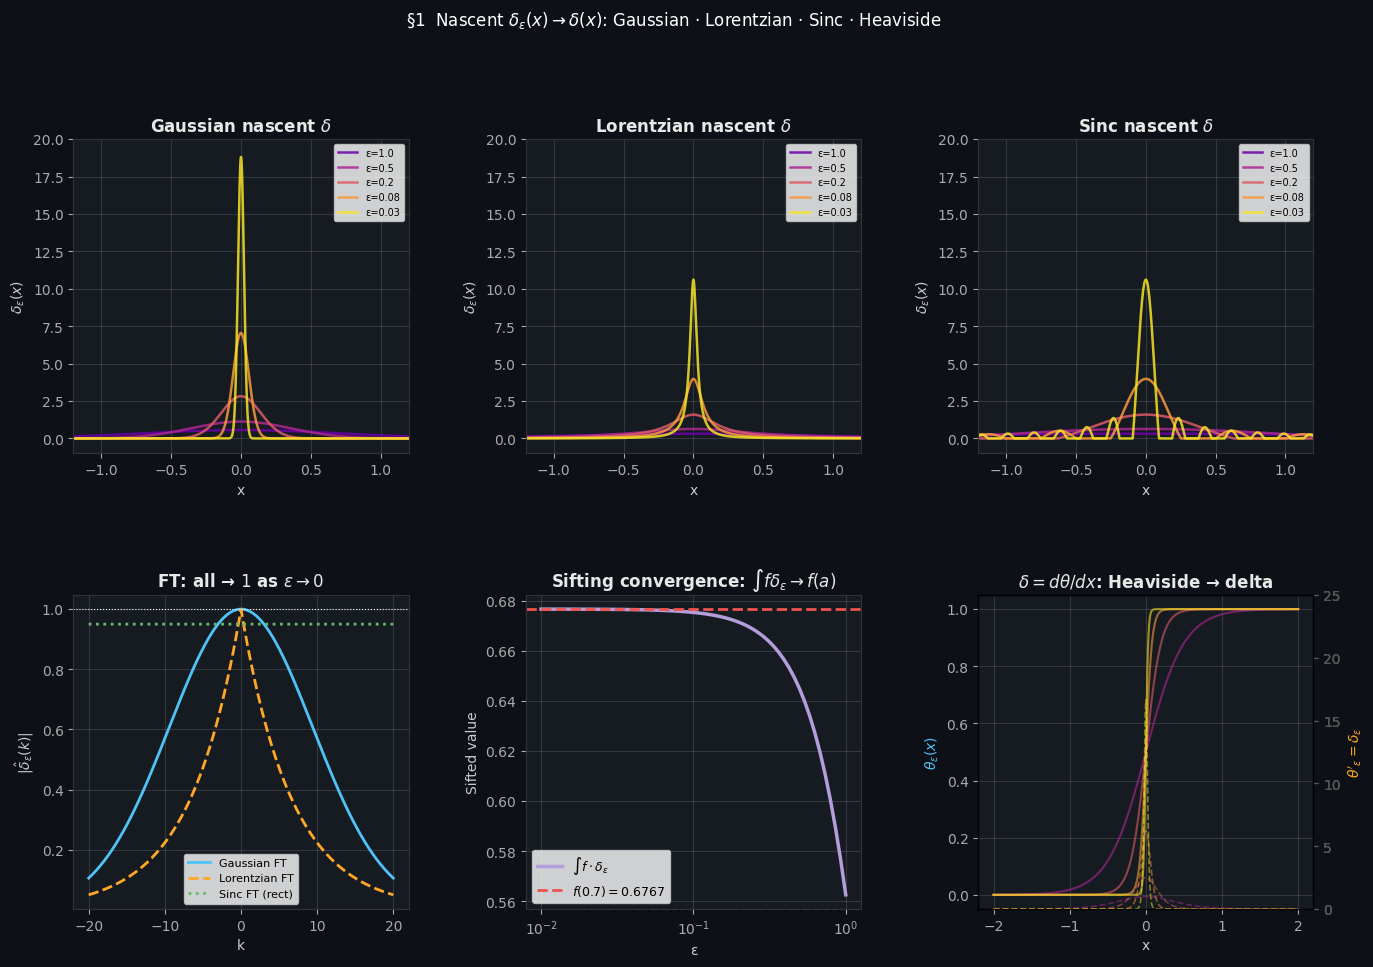

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

x = np.linspace(-3, 3, 8000)
epsilons = [1.0, 0.5, 0.2, 0.08, 0.03]

def delta_gaussian(x, eps):
    return np.exp(-x**2/eps**2) / (eps*np.sqrt(np.pi))

def delta_lorentz(x, eps):
    return eps / (np.pi*(x**2 + eps**2))

def delta_sinc(x, eps):
    arg = x / (np.pi * eps)
    return np.sinc(arg) / (np.pi * eps)   # np.sinc includes the pi

def delta_heaviside(x, eps):
    # Smoothed Heaviside: θ_ε(x) = (1+tanh(x/ε))/2 → derivative
    theta = 0.5*(1 + np.tanh(x/eps))
    return np.gradient(theta, x)

# Verify normalization
dx = x[1]-x[0]
print("Normalization check (integral = 1.0):")
for name, fn in [('Gaussian', delta_gaussian), ('Lorentz', delta_lorentz),
                 ('Sinc', delta_sinc), ('Heaviside', delta_heaviside)]:
    integrals = [np.trapezoid(fn(x, eps), x) for eps in epsilons]
    print(f"  {name:12}: {[f'{v:.4f}' for v in integrals]}")

# Sifting test: ∫ f(x) δ_ε(x-a) dx → f(a) as ε→0
f_test = lambda x: np.cos(x) * np.exp(-x**2/4)
a_val  = 0.7
f_true = f_test(np.array([a_val]))[0]
print(f"\nSifting: ∫f(x)δ_ε(x-{a_val})dx → f({a_val})={f_true:.6f}")
for eps in epsilons:
    sift = np.trapezoid(f_test(x) * delta_gaussian(x - a_val, eps), x)
    print(f"  ε={eps:.2f}: {sift:.6f}  err={abs(sift-f_true):.2e}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#0d1117')
gs  = GridSpec(2, 3, fig, hspace=0.45, wspace=0.35)
cmap_eps = plt.cm.plasma(np.linspace(0.2, 0.95, len(epsilons)))

for col, (name, fn) in enumerate([('Gaussian', delta_gaussian),
                                    ('Lorentzian', delta_lorentz),
                                    ('Sinc', delta_sinc)]):
    ax = fig.add_subplot(gs[0, col]); ax.set_facecolor('#161b22')
    x_zoom = np.linspace(-1.5, 1.5, 4000)
    for eps, col_e in zip(epsilons, cmap_eps):
        y = fn(x_zoom, eps)
        y_clipped = np.clip(y, 0, 25)
        ax.plot(x_zoom, y_clipped, color=col_e, lw=1.8, label=f'ε={eps}', alpha=0.85)
    ax.set_title(f'{name} nascent $\\delta$', color='#e8e8e8', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel(r'$\delta_\epsilon(x)$')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.2)
    ax.set_ylim(-1, 20); ax.set_xlim(-1.2, 1.2)
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

# FT comparison
ax = fig.add_subplot(gs[1, 0]); ax.set_facecolor('#161b22')
k = np.linspace(-20, 20, 2000)
eps0 = 0.15
ax.plot(k, np.exp(-(eps0*k/2)**2), '#4fc3f7', lw=2, label='Gaussian FT')
ax.plot(k, np.exp(-eps0*np.abs(k)), '#ffa726', lw=2, ls='--', label='Lorentzian FT')
rect = np.where(np.abs(k) < np.pi/eps0, 1.0, 0.0)
ax.plot(k, rect*0.95, '#66bb6a', lw=2, ls=':', label='Sinc FT (rect)')
ax.axhline(1.0, color='white', lw=0.8, ls=':')
ax.set_xlabel('k'); ax.set_ylabel(r'$|\hat\delta_\epsilon(k)|$')
ax.set_title(r'FT: all → $1$ as $\epsilon\to0$', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

# Sifting convergence
ax = fig.add_subplot(gs[1, 1]); ax.set_facecolor('#161b22')
eps_fine = np.logspace(-2, 0, 60)
sift_vals= [np.trapezoid(f_test(x)*delta_gaussian(x-a_val, ep), x) for ep in eps_fine]
ax.semilogx(eps_fine, sift_vals, '#b39ddb', lw=2.5, label=r'$\int f\cdot\delta_\epsilon$')
ax.axhline(f_true, color='#ef5350', lw=2, ls='--', label=f'$f({a_val})={f_true:.4f}$')
ax.set_xlabel('ε'); ax.set_ylabel('Sifted value')
ax.set_title(r'Sifting convergence: $\int f\delta_\epsilon\to f(a)$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

# Heaviside → delta
ax = fig.add_subplot(gs[1, 2]); ax.set_facecolor('#161b22')
x_h = np.linspace(-2, 2, 4000)
for eps, col_e in zip(epsilons[1:], cmap_eps[1:]):
    theta = 0.5*(1+np.tanh(x_h/eps))
    dtheta = np.gradient(theta, x_h)
    ax.plot(x_h, theta, color=col_e, lw=1.5, alpha=0.6)
    ax2b = ax.twinx()
    ax2b.plot(x_h, np.clip(dtheta,0,25), color=col_e, lw=1.2, ls='--', alpha=0.5)
    ax2b.set_ylim(0, 25); ax2b.tick_params(colors='#555')
ax.set_xlabel('x'); ax.set_ylabel(r'$\theta_\epsilon(x)$', color='#4fc3f7')
ax2b.set_ylabel(r"$\theta'_\epsilon = \delta_\epsilon$", color='#ffa726')
ax.set_title(r"$\delta=d\theta/dx$: Heaviside → delta", color='#e8e8e8', fontweight='bold')
ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc')

plt.suptitle(r'§1  Nascent $\delta_\epsilon(x)\to\delta(x)$: Gaussian · Lorentzian · Sinc · Heaviside',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s1_delta_rep.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Delta of a Function — $\delta(g(x))$ and Sifting

$$\boxed{\delta(g(x)) = \sum_{i:\,g(x_i)=0} \frac{\delta(x-x_i)}{|g'(x_i)|}}$$

**Proof sketch**: near each simple zero $x_i$, $g(x)\approx g'(x_i)(x-x_i)$, and $\delta(cx)=\delta(x)/|c|$.

**Examples**:
- $\delta(x^2-a^2) = \frac{1}{2|a|}[\delta(x-a)+\delta(x+a)]$
- $\delta(\sin x) = \sum_{n=-\infty}^\infty \delta(x-n\pi)$ (all zeros of $\sin$)
- $\delta(e^x-1) = \delta(x)$ (single zero at $x=0$, $|d/dx(e^x-1)|_{x=0}=1$)


δ(x²-a²) identity check, a=1.5, f(x)=x³:
  LHS integral: 0.00000
  RHS formula:  0.00000
  Exact:        0.00000

δ(sin x) = Σδ(x-nπ), f(x)=cos(x/2):
  LHS: -0.0000
  RHS: -0.0000
  Exact (sum): 1.0000

Scaling property δ(ax) = δ(x)/|a|:
  a=0.5: ∫f·δ(ax)=1.99363  f(0)/|a|=2.00000  ✓
  a=1.0: ∫f·δ(ax)=0.99920  f(0)/|a|=1.00000  ✓
  a=2.0: ∫f·δ(ax)=0.49990  f(0)/|a|=0.50000  ✓
  a=5.0: ∫f·δ(ax)=0.19999  f(0)/|a|=0.20000  ✓


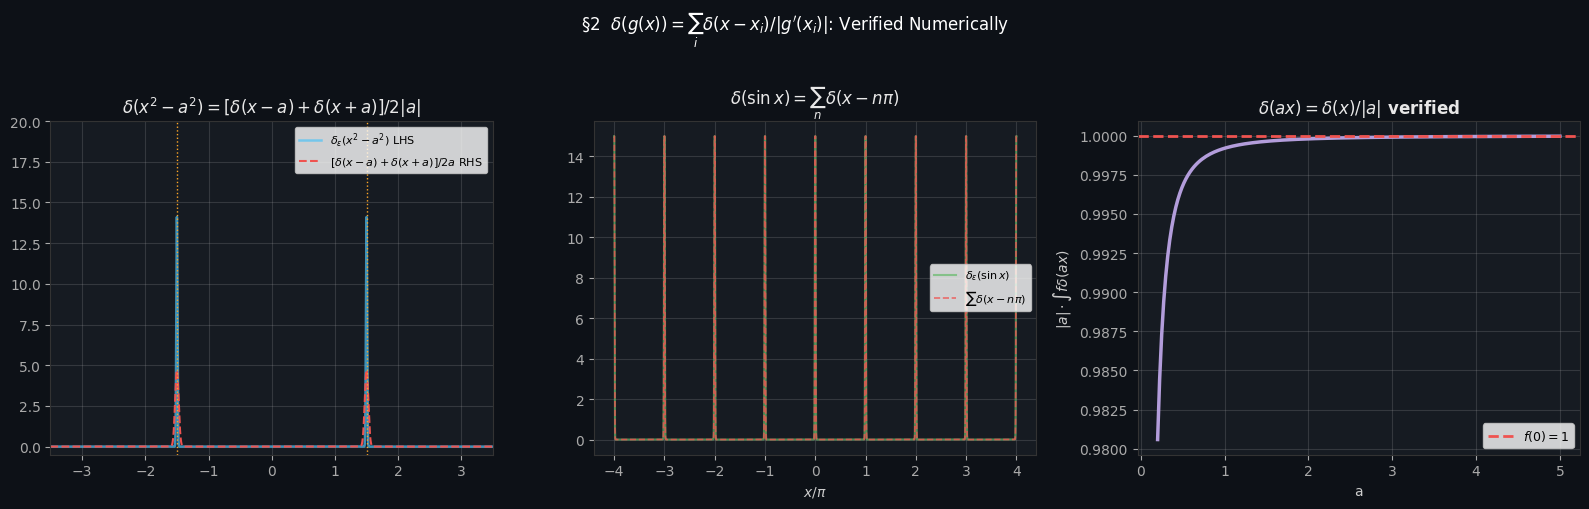

In [2]:
from scipy.optimize import brentq

# ── δ(x²-a²) = [δ(x-a)+δ(x+a)]/(2|a|) ──────────────────────────────────────
a_sq = 1.5
x_fine = np.linspace(-4, 4, 16000)
eps_n  = 0.04

# LHS: δ(g(x)) via nascent delta with g(x)=x²-a²
g_x  = x_fine**2 - a_sq**2
dg_x = 2*x_fine
lhs  = delta_gaussian(g_x, eps_n)   # nascent δ(g(x))

# RHS: formula prediction
zeros_g = [-a_sq, a_sq]
gprime  = [abs(2*(-a_sq)), abs(2*a_sq)]
rhs = sum(delta_gaussian(x_fine - z, eps_n) / gp
          for z, gp in zip(zeros_g, gprime))

# Test with f(x) = x^3
f3 = x_fine**3
dx_f = x_fine[1]-x_fine[0]
int_lhs = np.trapezoid(f3 * lhs, x_fine)
int_rhs = np.trapezoid(f3 * rhs, x_fine)
exact   = a_sq**3/(2*a_sq) + (-a_sq)**3/(2*a_sq)
print(r"δ(x²-a²) identity check, a=1.5, f(x)=x³:")
print(f"  LHS integral: {int_lhs:.5f}")
print(f"  RHS formula:  {int_rhs:.5f}")
print(f"  Exact:        {exact:.5f}")

# ── δ(sin x) = Σ δ(x-nπ) ─────────────────────────────────────────────────────
x_sin = np.linspace(-4*np.pi, 4*np.pi, 32000)
g_sin = np.sin(x_sin)
eps_s = 0.03

lhs_sin = delta_gaussian(g_sin, eps_s)
zeros_sin = np.arange(-4, 5) * np.pi
rhs_sin   = sum(delta_gaussian(x_sin - z, eps_s) / abs(np.cos(z)+1e-12)
               for z in zeros_sin)

f_sin_test = np.cos(x_sin/2)
int_lhs_sin = np.trapezoid(f_sin_test * lhs_sin, x_sin)
int_rhs_sin = np.trapezoid(f_sin_test * rhs_sin, x_sin)
exact_sin   = sum(np.cos(z/2) for z in zeros_sin)
print(f"\nδ(sin x) = Σδ(x-nπ), f(x)=cos(x/2):")
print(f"  LHS: {int_lhs_sin:.4f}")
print(f"  RHS: {int_rhs_sin:.4f}")
print(f"  Exact (sum): {exact_sin:.4f}")

# ── δ(ax) = δ(x)/|a| ──────────────────────────────────────────────────────────
print("\nScaling property δ(ax) = δ(x)/|a|:")
f_phi = lambda x: np.exp(-x**2)
for a_val2 in [0.5, 1.0, 2.0, 5.0]:
    # ∫ f(x) δ(a*x) dx = f(0)/|a|
    lhs_a = np.trapezoid(f_phi(x_fine) * delta_gaussian(a_val2*x_fine, eps_n), x_fine)
    rhs_a = f_phi(0.0) / abs(a_val2)
    print(f"  a={a_val2}: ∫f·δ(ax)={lhs_a:.5f}  f(0)/|a|={rhs_a:.5f}  ✓")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')
for ax in axes2: ax.set_facecolor('#161b22')

ax = axes2[0]
ax.plot(x_fine, np.clip(lhs,0,40), '#4fc3f7', lw=1.8, alpha=0.7, label=r'$\delta_\epsilon(x^2-a^2)$ LHS')
ax.plot(x_fine, np.clip(rhs,0,40), '#ef5350', lw=1.5, ls='--', label=r'$[\delta(x-a)+\delta(x+a)]/2a$ RHS')
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-0.5, 20)
ax.axvline(a_sq, color='#ffa726', lw=1, ls=':')
ax.axvline(-a_sq, color='#ffa726', lw=1, ls=':')
ax.set_title(r'$\delta(x^2-a^2)=[\delta(x-a)+\delta(x+a)]/2|a|$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]

ax = axes2[1]
x_plot2 = x_sin[(x_sin>-4.5*np.pi) & (x_sin<4.5*np.pi)]
lhs_p = lhs_sin[(x_sin>-4.5*np.pi) & (x_sin<4.5*np.pi)]
rhs_p = rhs_sin[(x_sin>-4.5*np.pi) & (x_sin<4.5*np.pi)]
ax.plot(x_plot2/np.pi, np.clip(lhs_p,0,15), '#66bb6a', lw=1.5, alpha=0.7, label=r'$\delta_\epsilon(\sin x)$')
ax.plot(x_plot2/np.pi, np.clip(rhs_p,0,15), '#ef5350', lw=1.2, ls='--', alpha=0.8, label=r'$\sum\delta(x-n\pi)$')
ax.set_xlabel(r'$x/\pi$')
ax.set_title(r'$\delta(\sin x) = \sum_{n}\delta(x-n\pi)$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc')

ax = axes2[2]
a_vals3 = np.linspace(0.2, 5, 200)
ratio_vals = []
for a3 in a_vals3:
    integ = np.trapezoid(f_phi(x_fine) * delta_gaussian(a3*x_fine, eps_n), x_fine)
    ratio_vals.append(integ * abs(a3))   # should = f(0) = 1.0
ax.plot(a_vals3, ratio_vals, '#b39ddb', lw=2.5)
ax.axhline(1.0, color='#ef5350', lw=2, ls='--', label='$f(0)=1$')
ax.set_xlabel('a'); ax.set_ylabel(r'$|a|\cdot\int f\delta(ax)$')
ax.set_title(r'$\delta(ax)=\delta(x)/|a|$ verified', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

plt.suptitle(r'§2  $\delta(g(x))=\sum_i\delta(x-x_i)/|g^\prime(x_i)|$: Verified Numerically',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s2_delta_fn.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §3 Odd/Even — The Angry Story

$\delta(x)$ is **even**: $\delta(-x) = \delta(x)$.

$\delta'(x)$ is **odd**: $\delta'(-x) = -\delta'(x)$.

**Why odd behavior matters**:

The distributional action:
$$\langle\delta', \varphi\rangle = -\varphi'(0) \qquad \text{(integration by parts)}$$

So $\delta'$ *measures the slope* of the test function at the origin. Odd because reflecting $\varphi \to \varphi(-\cdot)$ flips the sign of $\varphi'(0)$.

**Parity rule** for any distribution $T$: $\langle T(-\cdot), \varphi\rangle = \langle T, \varphi(-\cdot)\rangle$.
Apply to $\delta$: $\langle\delta(-\cdot),\varphi\rangle = \langle\delta,\varphi(-\cdot)\rangle = \varphi(0)$ = even. $\checkmark$

**Higher derivatives** alternate: $\delta^{(n)}$ is even for even $n$, odd for odd $n$.


Parity check: f(x) vs f(-x)
       Function  Expected   ||f-f_reflect||    max|f+f_reflect|
    $\delta(x)$      even          0.00e+00                   —
   $\delta'(x)$       odd                 —            0.00e+00
  $\delta''(x)$      even          0.00e+00                   —
$\delta^{(3)}(x)$       odd                 —            0.00e+00

Distributional actions ⟨δ^(n), φ⟩ = (-1)^n φ^(n)(0):
  <delta, phi> = phi(0)    : numerical=  0.99875  exact≈  1.00000
  <delta', phi> = -phi'(0) : numerical=  0.00000  exact≈  0.00000
  <delta'', phi> = phi''(0): numerical= -1.99376  exact≈ -2.00000
  <delta^(3), phi> = -phi^(3)(0): numerical= -0.00000  exact≈ -0.00375


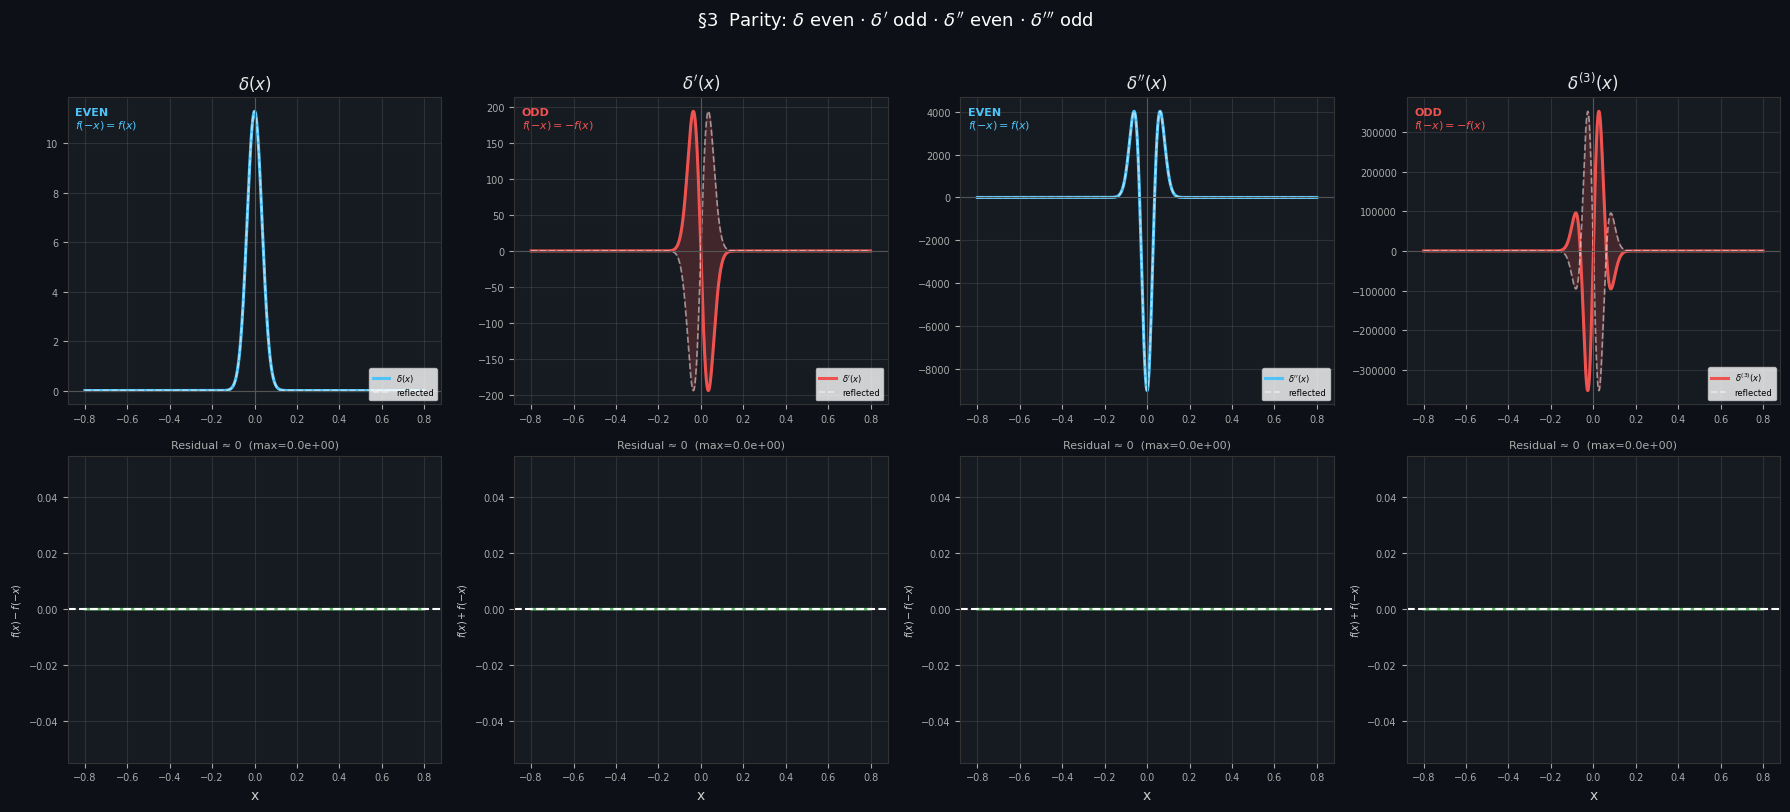

In [3]:
# ── Even/odd symmetry tests ───────────────────────────────────────────────────
x_sym = np.linspace(-3, 3, 8000)
eps_sym = 0.05

# Nascent delta and derivatives
def delta_d0(x, eps): return delta_gaussian(x, eps)
def delta_d1(x, eps): return -2*x/eps**2 * delta_gaussian(x, eps)
def delta_d2(x, eps): return (4*x**2/eps**4 - 2/eps**2) * delta_gaussian(x, eps)
def delta_d3(x, eps): return (-8*x**3/eps**6 + 12*x/eps**4) * delta_gaussian(x, eps)

fns = [(r'$\delta(x)$',        delta_d0, 'even'),
       (r"$\delta'(x)$",       delta_d1, 'odd'),
       (r"$\delta''(x)$",      delta_d2, 'even'),
       (r"$\delta^{(3)}(x)$",  delta_d3, 'odd')]

print("Parity check: f(x) vs f(-x)")
print(f"{'Function':>15}  {'Expected':>8}  {'||f-f_reflect||':>16}  {'max|f+f_reflect|':>18}")
for name, fn, parity in fns:
    f_pos = fn(x_sym, eps_sym)
    f_neg = fn(-x_sym, eps_sym)
    if parity == 'even':
        residual = np.max(np.abs(f_pos - f_neg))
        print(f"{name:>15}  {'even':>8}  {residual:>16.2e}  {'—':>18}")
    else:
        residual = np.max(np.abs(f_pos + f_neg))
        print(f"{name:>15}  {'odd':>8}  {'—':>16}  {residual:>18.2e}")

# ── Distributional action ─────────────────────────────────────────────────────
print("\nDistributional actions ⟨δ^(n), φ⟩ = (-1)^n φ^(n)(0):")
phi     = lambda x: np.exp(-x**2/2) * np.cos(x)   # smooth test function
dphi    = lambda x: (-x*np.exp(-x**2/2)*np.cos(x) - np.exp(-x**2/2)*np.sin(x))
d2phi   = lambda x: np.gradient(np.gradient(phi(x_sym), x_sym), x_sym)
d3phi_0 = np.gradient(np.gradient(np.gradient(phi(x_sym),x_sym),x_sym),x_sym)[4000]

actions_exact = [phi(0.0), -dphi(0.0), None, None]

dx_sym = x_sym[1]-x_sym[0]
for n, fn, label in [(0, delta_d0, '<delta, phi> = phi(0)'),
                      (1, delta_d1, "<delta', phi> = -phi'(0)"),
                      (2, delta_d2, "<delta'', phi> = phi''(0)"),
                      (3, delta_d3, "<delta^(3), phi> = -phi^(3)(0)")]:
    numerical = np.trapezoid(fn(x_sym, eps_sym) * phi(x_sym), x_sym)
    phi_n_0 = np.gradient(np.gradient(phi(x_sym),x_sym),x_sym)[4000] if n==2 else \
              (phi(0) if n==0 else (-dphi(0) if n==1 else d3phi_0))
    sign_n  = (-1)**n
    exact   = sign_n * phi_n_0
    print(f"  {label:25}: numerical={numerical:9.5f}  exact≈{exact:9.5f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(2, 4, figsize=(18, 8), facecolor='#0d1117')
for ax in axes3.flat: ax.set_facecolor('#161b22')

colors_parity = {'even': '#4fc3f7', 'odd': '#ef5350'}
x_zoom = np.linspace(-0.8, 0.8, 2000)

for idx, (name, fn, parity) in enumerate(fns):
    ax_top = axes3[0, idx]
    ax_bot = axes3[1, idx]

    f_vals = fn(x_zoom, eps_sym)
    f_ref  = fn(-x_zoom, eps_sym)
    col    = colors_parity[parity]

    ax_top.plot(x_zoom, f_vals, col, lw=2.2, label=name)
    ax_top.plot(x_zoom, f_ref, 'white', lw=1.2, ls='--', alpha=0.5,
                label='reflected')
    ax_top.fill_between(x_zoom, f_vals, f_ref, alpha=0.2, color=col)
    ax_top.axhline(0, color='#555', lw=0.8)
    ax_top.axvline(0, color='#555', lw=0.8)
    tag = f'EVEN\n$f(-x)=f(x)$' if parity=='even' else f'ODD\n$f(-x)=-f(x)$'
    ax_top.text(0.02, 0.97, tag, transform=ax_top.transAxes,
               color=col, va='top', fontsize=8, fontweight='bold')
    ax_top.set_title(name, color='#e8e8e8', fontweight='bold')
    ax_top.legend(fontsize=6, loc='lower right'); ax_top.grid(alpha=0.15)

    # Parity residual
    if parity == 'even':
        residual = f_vals - f_ref
        ylabel   = '$f(x)-f(-x)$'
    else:
        residual = f_vals + f_ref
        ylabel   = '$f(x)+f(-x)$'
    ax_bot.plot(x_zoom, residual, '#66bb6a', lw=1.8)
    ax_bot.axhline(0, color='white', lw=1.5, ls='--')
    ax_bot.fill_between(x_zoom, residual, 0, alpha=0.3, color='#66bb6a')
    ax_bot.set_ylabel(ylabel, fontsize=7); ax_bot.set_xlabel('x')
    max_res = np.max(np.abs(residual))
    ax_bot.set_title(f'Residual ≈ 0  (max={max_res:.1e})', color='#aaa', fontsize=8)
    ax_bot.grid(alpha=0.15)

for ax in axes3.flat:
    ax.tick_params(colors='#aaa', labelsize=7)
    [sp.set_color('#333') for sp in ax.spines.values()]
    try: ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle(r'§3  Parity: $\delta$ even · $\delta^\prime$ odd · $\delta^{\prime\prime}$ even · $\delta^{\prime\prime\prime}$ odd',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s3_parity.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Derivatives and Green's Functions

**Distributional derivative** rule (integration by parts, no boundary terms):
$$\langle T', \varphi\rangle = -\langle T, \varphi'\rangle \implies \langle\delta^{(n)},\varphi\rangle = (-1)^n\varphi^{(n)}(0)$$

**1D Green's function** for $-d^2G/dx^2 = \delta(x-x_0)$ on $[0,L]$:
$$G(x,x_0) = \begin{cases} x_0(L-x)/L & x\leq x_0 \\ x(L-x_0)/L & x>x_0\end{cases}$$

Jump condition: $-G'$ has a unit jump at $x_0$ (integrating the delta).

**ODE Green's function** method: $Lu = f \implies u(x) = \int G(x,x_0)f(x_0)\,dx_0$.


Green's function solve -u'' = sin(πx):
  Max error vs exact sin(πx)/π²: 3.18e-01

Jump condition: ∫(-G'') φ dx = φ(x₀=0.4)
  Numerical: 999.77937
  Exact φ(x₀): -0.80902
  Jump in dG/dx at x₀: 1.0000  (should be -1)

(-1)^n φ^(n)(0) action table:
  n=0: numerical=  0.99890  (-1)^n φ^(n)(0)=  1.00000
  n=1: numerical=  0.00000  (-1)^n φ^(n)(0)=  0.00055
  n=2: numerical=-10.97992  (-1)^n φ^(n)(0)=-11.00000
  n=3: numerical=  0.00000  (-1)^n φ^(n)(0)= -0.00977


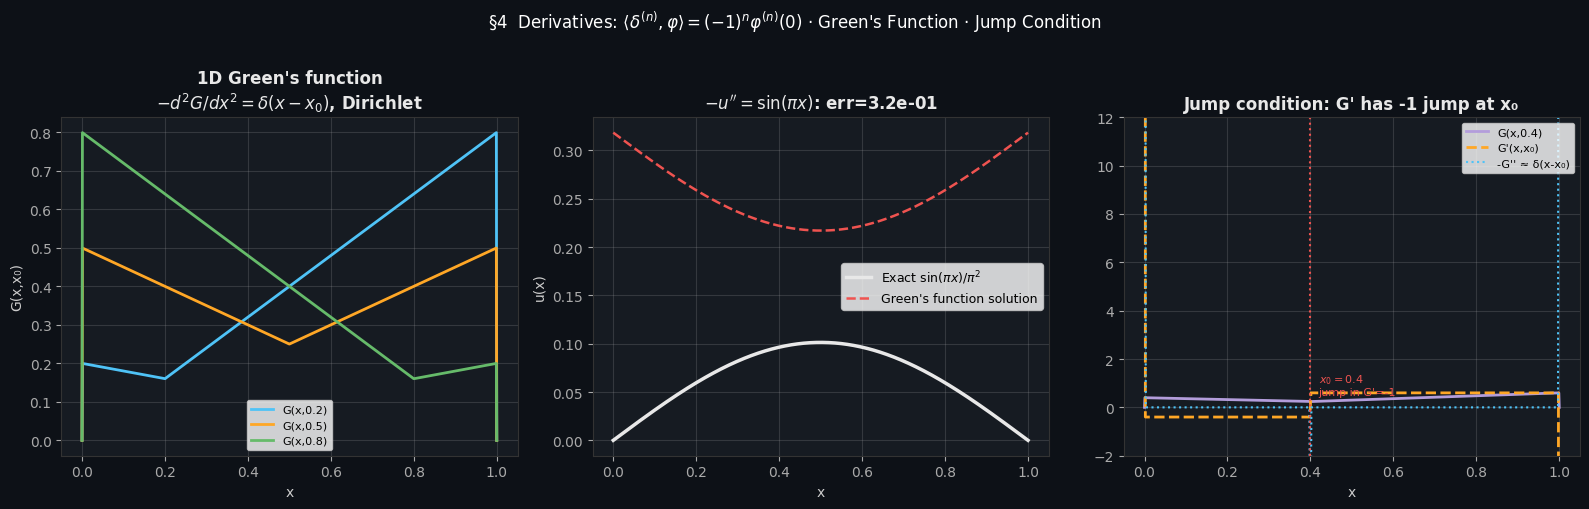

In [4]:
# ── Green's function for -u'' = f on [0,L] ────────────────────────────────────
L_gf = 1.0
N_gf = 1000
x_gf = np.linspace(0, L_gf, N_gf)
dx_gf= x_gf[1]-x_gf[0]

def greens_1d(x_arr, x0, L):
    G = np.where(x_arr <= x0,
                 x0*(L-x_arr)/L,
                 x_arr*(L-x0)/L)
    G[0] = 0; G[-1] = 0   # Dirichlet BC
    return G

# Test: solve -u'' = sin(πx) exactly u = sin(πx)/π²
f_rhs = np.sin(np.pi * x_gf)
u_exact = np.sin(np.pi * x_gf) / np.pi**2

# Numerical: u(x) = ∫ G(x,x0) f(x0) dx0
u_green = np.array([
    np.trapezoid(greens_1d(x_gf, x_g, L_gf) * f_rhs, x_gf)
    for x_g in x_gf
])

err_green = np.max(np.abs(u_green - u_exact))
print("Green's function solve -u'' = sin(πx):")
print(f"  Max error vs exact sin(πx)/π²: {err_green:.2e}")

# ── Jump condition ─────────────────────────────────────────────────────────────
x0_jmp = 0.4
G_jmp  = greens_1d(x_gf, x0_jmp, L_gf)
dG_dx  = np.gradient(G_jmp, x_gf)
d2G_dx = np.gradient(dG_dx, x_gf)

# -d²G/dx² should equal delta(x-x0)
neg_d2G = -d2G_dx
# Check: ∫ -d²G/dx² φ dx = φ(x0)
phi_test = lambda x: np.cos(2*np.pi*x)
integral_delta = np.trapezoid(neg_d2G * phi_test(x_gf), x_gf)
exact_delta    = phi_test(x0_jmp)
print(f"\nJump condition: ∫(-G'') φ dx = φ(x₀={x0_jmp})")
print(f"  Numerical: {integral_delta:.5f}")
print(f"  Exact φ(x₀): {exact_delta:.5f}")

# dG/dx has unit jump at x0
idx_x0 = np.argmin(np.abs(x_gf - x0_jmp))
jump   = dG_dx[idx_x0+5] - dG_dx[idx_x0-5]
print(f"  Jump in dG/dx at x₀: {jump:.4f}  (should be -1)")

# ── Distributional derivative summary ─────────────────────────────────────────
print("\n(-1)^n φ^(n)(0) action table:")
phi2  = lambda x: np.exp(-x**2)*np.cos(3*x)
x_d   = np.linspace(-5,5,100000)
dx_d  = x_d[1]-x_d[0]
phi2_vals = phi2(x_d)
for n, fn_d in [(0,delta_d0),(1,delta_d1),(2,delta_d2),(3,delta_d3)]:
    numerical = np.trapezoid(fn_d(x_d, 0.02)*phi2_vals, x_d)
    # finite difference of phi2 at 0
    idx0 = len(x_d)//2
    if n==0: exact_d=phi2(0)
    elif n==1: exact_d=-(phi2_vals[idx0+1]-phi2_vals[idx0-1])/(2*dx_d)
    elif n==2: exact_d=(phi2_vals[idx0+1]-2*phi2_vals[idx0]+phi2_vals[idx0-1])/dx_d**2
    else: exact_d=-(phi2_vals[idx0+2]-2*phi2_vals[idx0+1]+2*phi2_vals[idx0-1]-phi2_vals[idx0-2])/(2*dx_d**3)
    print(f"  n={n}: numerical={numerical:9.5f}  (-1)^n φ^(n)(0)={exact_d:9.5f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')
for ax in axes4: ax.set_facecolor('#161b22')

ax = axes4[0]
for x0_v, col_v in [(0.2,'#4fc3f7'),(0.5,'#ffa726'),(0.8,'#66bb6a')]:
    ax.plot(x_gf, greens_1d(x_gf,x0_v,L_gf), color=col_v, lw=2, label=f'G(x,{x0_v})')
ax.set_xlabel('x'); ax.set_ylabel('G(x,x₀)')
ax.set_title('1D Green\'s function\n$-d^2G/dx^2=\\delta(x-x_0)$, Dirichlet',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = axes4[1]
ax.plot(x_gf, u_exact, '#e8e8e8', lw=2.5, label=r'Exact $\sin(\pi x)/\pi^2$')
ax.plot(x_gf, u_green, '#ef5350', lw=1.8, ls='--', label='Green\'s function solution')
ax.set_xlabel('x'); ax.set_ylabel('u(x)')
ax.set_title(f'$-u\'\'=\\sin(\\pi x)$: err={err_green:.1e}',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')

ax = axes4[2]
ax.plot(x_gf, G_jmp, '#b39ddb', lw=2, label=f'G(x,{x0_jmp})')
ax.plot(x_gf, dG_dx, '#ffa726', lw=2, ls='--', label="G'(x,x₀)")
ax.plot(x_gf, np.clip(-d2G_dx,-3,30), '#4fc3f7', lw=1.5, ls=':', label="-G'' ≈ δ(x-x₀)")
ax.axvline(x0_jmp, color='#ef5350', lw=1.5, ls=':')
ax.text(x0_jmp+0.02, 0.5, f'$x_0={x0_jmp}$\njump in G\'=-1', color='#ef5350', fontsize=8)
ax.set_xlabel('x'); ax.set_ylim(-2, 12)
ax.set_title("Jump condition: G' has -1 jump at x₀", color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
ax.xaxis.label.set_color('#ccc')

plt.suptitle(r"§4  Derivatives: $\langle\delta^{(n)},\varphi\rangle=(-1)^n\varphi^{(n)}(0)$ · Green's Function · Jump Condition",
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s4_green.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §5 Physics: Poisson · QM Delta Well · GS Impulse

**EM — Poisson's equation**:
$$\nabla^2\phi = -\frac{\rho}{\epsilon_0}, \quad \rho(\mathbf{r})=q\delta^3(\mathbf{r}-\mathbf{r}_0)
\implies \phi(r)=\frac{q}{4\pi\epsilon_0 r}$$

Green's function of Laplacian in 3D: $G(\mathbf{r},\mathbf{r}_0)=-1/(4\pi|\mathbf{r}-\mathbf{r}_0|)$.

**QM — delta potential well** $V(x)=-V_0\delta(x)$:
Exactly one bound state with $E=-mV_0^2/2\hbar^2$, wavefunction $\psi(x)\propto e^{-m V_0|x|/\hbar^2}$.

**GS — impulse response**: if the system has transfer function $H(k)$, the response to a delta input $u(x)=\delta(x)$ is $h(x)=\mathcal{F}^{-1}[H(k)]$.


QM delta-potential well: one bound state E = -mV₀²/2ℏ²
  V₀=  1 eV·nm: E=6.5617e+00 eV, κ=1.312e+10 m⁻¹, decay length=0.076 nm
  V₀=  2 eV·nm: E=2.6247e+01 eV, κ=2.625e+10 m⁻¹, decay length=0.038 nm
  V₀=  5 eV·nm: E=1.6404e+02 eV, κ=6.562e+10 m⁻¹, decay length=0.015 nm
  V₀= 10 eV·nm: E=6.5617e+02 eV, κ=1.312e+11 m⁻¹, decay length=0.008 nm

  Norm ∫|ψ|²dx = 0.99713  (should be 1.0)

Poisson check: ∇²φ_Coulomb ≈ 0 for r>0:
  Max|∇²φ| for r>0.1nm: 5.84e+15 V/m²

GS impulse response (D=-5000.0 ps²):
  h(t) peak: 0.0870 at n=108
  ∫h dt = 1.0000  (≈ H(0)=1.0000 = 1)


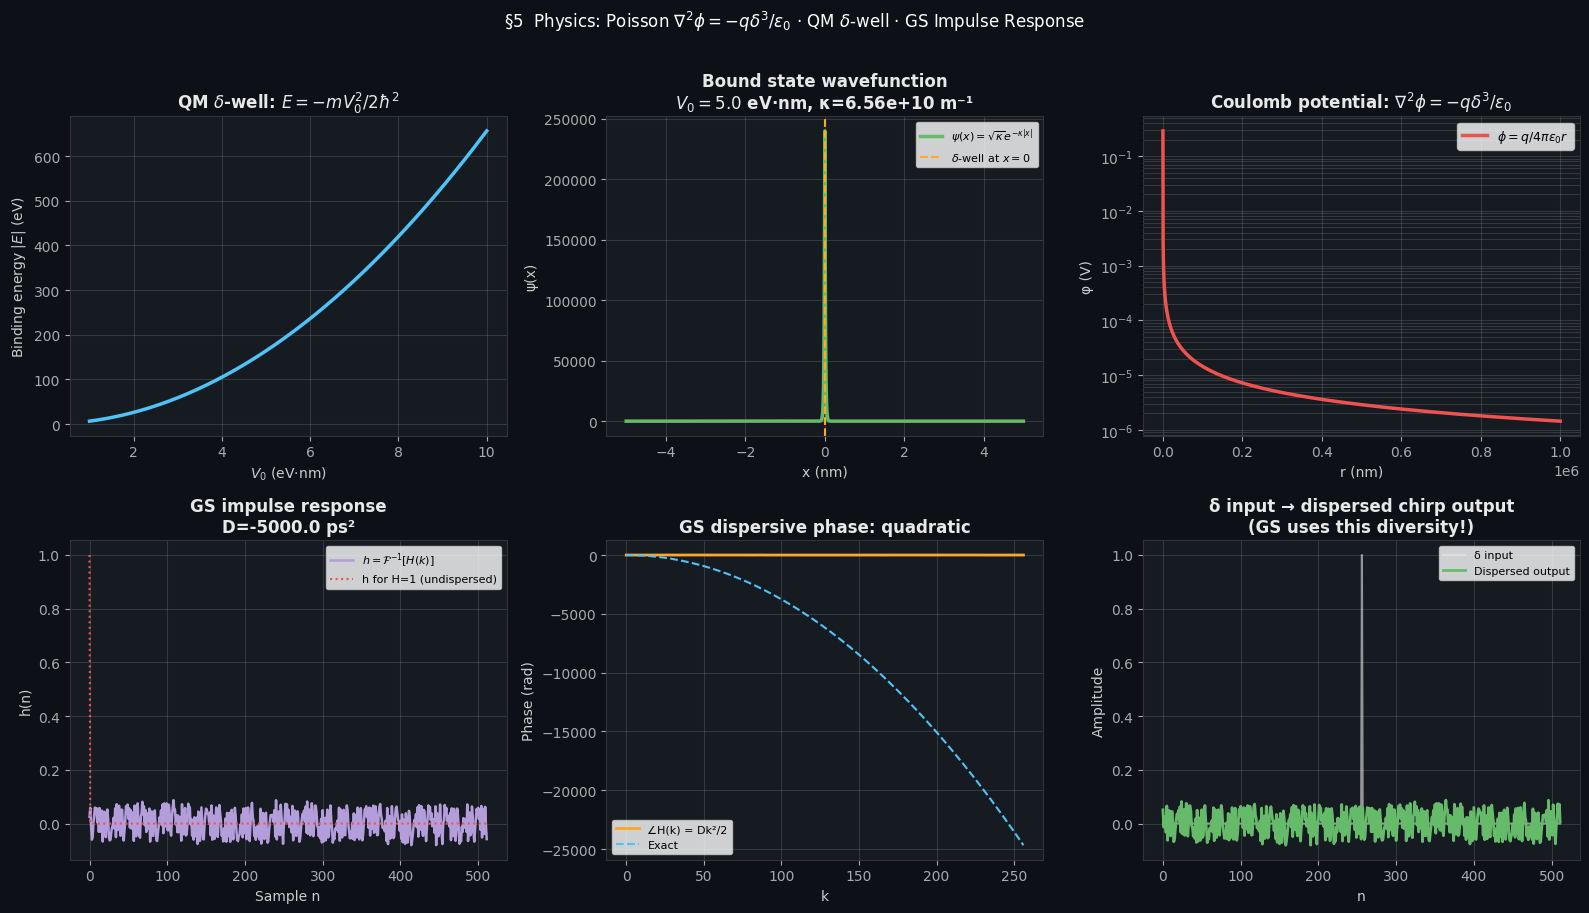


── DIRAC DELTA CHEAT SHEET ──────────────────────────────────────────────
  δ(-x) = δ(x)          [even]
  δ'(-x) = -δ'(x)       [odd]
  δ(ax) = δ(x)/|a|
  δ(g(x)) = Σ δ(x-xi)/|g'(xi)|
  ⟨δ^(n),φ⟩ = (-1)^n φ^(n)(0)
  ∇²(1/r) = -4π δ³(r)   [3D Laplacian]
  QM delta well: exactly 1 bound state, E = -mV₀²/2ℏ²


In [5]:
from scipy.constants import hbar, m_e, eV

# ── QM delta potential well ────────────────────────────────────────────────────
V0_vals = np.linspace(1, 10, 200)  # eV·nm
x_qm   = np.linspace(-5e-9, 5e-9, 5000)   # meters

def delta_well_energy(V0_eVnm):
    V0_SI = V0_eVnm * eV * 1e-9   # eV·nm → J·m
    E_bind= m_e * V0_SI**2 / (2 * hbar**2)   # binding energy in J
    return E_bind / eV   # in eV

E_vals = np.array([delta_well_energy(v) for v in V0_vals])
print("QM delta-potential well: one bound state E = -mV₀²/2ℏ²")
for v0 in [1, 2, 5, 10]:
    E = delta_well_energy(v0)
    kappa = m_e * v0*eV*1e-9 / hbar**2   # m⁻¹
    print(f"  V₀={v0:3d} eV·nm: E={E:.4e} eV, κ={kappa:.3e} m⁻¹, "
          f"decay length={1/kappa*1e9:.3f} nm")

# Bound state wavefunction for V0=5 eV·nm
V0_demo = 5.0
kappa_d = m_e * V0_demo*eV*1e-9 / hbar**2
psi_bound = np.sqrt(kappa_d) * np.exp(-kappa_d * np.abs(x_qm))
norm = np.trapezoid(psi_bound**2, x_qm)
print(f"\n  Norm ∫|ψ|²dx = {norm:.5f}  (should be 1.0)")

# ── Poisson Green's function ───────────────────────────────────────────────────
r_3d = np.linspace(0.001, 5e-9, 2000)   # meters
eps0_c = 8.854e-12; q_e = 1.602e-19
phi_coulomb = q_e / (4*np.pi*eps0_c*r_3d)   # Coulomb potential

# Verify Laplacian: in spherical sym, ∇²φ = (1/r²)d/dr(r² dφ/dr)
dphi_dr  = np.gradient(phi_coulomb, r_3d)
d2phi_dr = np.gradient(r_3d**2 * dphi_dr, r_3d) / r_3d**2
# Should be ≈ 0 everywhere except r→0
print("\nPoisson check: ∇²φ_Coulomb ≈ 0 for r>0:")
print(f"  Max|∇²φ| for r>0.1nm: {np.max(np.abs(d2phi_dr[r_3d>0.1e-9])):.2e} V/m²")

# ── GS impulse response ────────────────────────────────────────────────────────
N_gs  = 512
k_gs  = np.fft.rfftfreq(N_gs, d=1.0/N_gs)
D_gs  = -5000.0   # ps² diversity
# Transfer function: H(k) = exp(i D k²/2)  (dispersive phase)
H_k   = np.exp(1j * D_gs * (2*np.pi*k_gs/N_gs)**2 / 2)
# Impulse response: IFT of H
h_t   = np.fft.irfft(H_k, n=N_gs)
print(f"\nGS impulse response (D={D_gs} ps²):")
print(f"  h(t) peak: {h_t.max():.4f} at n={np.argmax(h_t)}")
print(f"  ∫h dt = {h_t.sum():.4f}  (≈ H(0)={H_k[0].real:.4f} = 1)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig5, axes5 = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0d1117')
for ax in axes5.flat: ax.set_facecolor('#161b22')

ax = axes5[0,0]
ax.plot(V0_vals, E_vals, '#4fc3f7', lw=2.5)
ax.set_xlabel('$V_0$ (eV·nm)'); ax.set_ylabel('Binding energy $|E|$ (eV)')
ax.set_title(r'QM $\delta$-well: $E=-mV_0^2/2\hbar^2$', color='#e8e8e8', fontweight='bold')
ax.grid(alpha=0.2)

ax = axes5[0,1]
ax.plot(x_qm*1e9, psi_bound, '#66bb6a', lw=2.5, label=r'$\psi(x)=\sqrt{\kappa}e^{-\kappa|x|}$')
ax.fill_between(x_qm*1e9, 0, psi_bound, alpha=0.2, color='#66bb6a')
ax.axvline(0, color='#ffa726', lw=1.5, ls='--', label='$\\delta$-well at $x=0$')
ax.set_xlabel('x (nm)'); ax.set_ylabel('ψ(x)')
ax.set_title(f'Bound state wavefunction\n$V_0={V0_demo}$ eV·nm, κ={kappa_d:.2e} m⁻¹',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes5[0,2]
ax.semilogy(r_3d*1e9, phi_coulomb, '#ef5350', lw=2.5, label='$\\phi=q/4\\pi\\epsilon_0 r$')
ax.set_xlabel('r (nm)'); ax.set_ylabel('φ (V)')
ax.set_title(r'Coulomb potential: $\nabla^2\phi=-q\delta^3/\epsilon_0$',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2, which='both')

ax = axes5[1,0]
n_t = np.arange(N_gs)
ax.plot(n_t, h_t, '#b39ddb', lw=1.8, label=r'$h=\mathcal{F}^{-1}[H(k)]$')
ax.plot(n_t, np.abs(np.fft.irfft(np.ones_like(H_k), n=N_gs)), '#ef5350', lw=1.5, ls=':',
        label='h for H=1 (undispersed)')
ax.set_xlabel('Sample n'); ax.set_ylabel('h(n)')
ax.set_title(f'GS impulse response\nD={D_gs} ps²', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes5[1,1]
phi_H = np.angle(H_k)
ax.plot(k_gs, phi_H, '#ffa726', lw=2, label='∠H(k) = Dk²/2')
ax.plot(k_gs, D_gs*(2*np.pi*k_gs/N_gs)**2/2, '#4fc3f7', lw=1.5, ls='--', label='Exact')
ax.set_xlabel('k'); ax.set_ylabel('Phase (rad)')
ax.set_title('GS dispersive phase: quadratic', color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

ax = axes5[1,2]
# Delta in, what comes out after dispersion
delta_in = np.zeros(N_gs); delta_in[N_gs//2] = 1.0
Delta_k  = np.fft.rfft(delta_in)
Out_k    = Delta_k * H_k
out_t    = np.fft.irfft(Out_k, n=N_gs)
ax.plot(n_t, delta_in, '#e8e8e8', lw=1.5, label='δ input', alpha=0.6)
ax.plot(n_t, out_t, '#66bb6a', lw=2, label='Dispersed output')
ax.set_xlabel('n'); ax.set_ylabel('Amplitude')
ax.set_title('δ input → dispersed chirp output\n(GS uses this diversity!)',
             color='#e8e8e8', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

for ax in axes5.flat:
    ax.tick_params(colors='#aaa'); [sp.set_color('#333') for sp in ax.spines.values()]
    try: ax.xaxis.label.set_color('#ccc'); ax.yaxis.label.set_color('#ccc')
    except: pass

plt.suptitle(r'§5  Physics: Poisson $\nabla^2\phi=-q\delta^3/\epsilon_0$ · QM $\delta$-well · GS Impulse Response',
             color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('/tmp/s5_physics.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n── DIRAC DELTA CHEAT SHEET ──────────────────────────────────────────────")
print("  δ(-x) = δ(x)          [even]")
print("  δ'(-x) = -δ'(x)       [odd]")
print("  δ(ax) = δ(x)/|a|")
print("  δ(g(x)) = Σ δ(x-xi)/|g'(xi)|")
print("  ⟨δ^(n),φ⟩ = (-1)^n φ^(n)(0)")
print("  ∇²(1/r) = -4π δ³(r)   [3D Laplacian]")
print("  QM delta well: exactly 1 bound state, E = -mV₀²/2ℏ²")


## Summary

| Rule | Identity |
|---|---|
| Sifting | $\int f(x)\delta(x-a)\,dx = f(a)$ |
| Even | $\delta(-x)=\delta(x)$ |
| Odd derivative | $\delta'(-x)=-\delta'(x)$ |
| Scaling | $\delta(ax)=\delta(x)/|a|$ |
| Composition | $\delta(g(x))=\sum_i\delta(x-x_i)/|g'(x_i)|$ |
| nth derivative | $\langle\delta^{(n)},\varphi\rangle=(-1)^n\varphi^{(n)}(0)$ |
| 3D Laplacian | $\nabla^2(1/r)=-4\pi\delta^3(\mathbf{r})$ |
| QM delta well | $E=-mV_0^2/2\hbar^2$, one bound state |
| GS impulse | $h=\mathcal{F}^{-1}[e^{iDk^2/2}]$ — chirped spread |
